In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import keras_hub
import json
import keras


# Plot functions
sns.set_style("darkgrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

train_color = "#2E86AB"  # Deep blue
val_color = "#A23B72"    # Deep magenta

color_palette = ["#a6cee3", "#1f78b4","#b2df8a", "#33a02c","#fb9a99","#e31a1c"]
model_versions = ["0.0", "1.0", "1.1", "1.2", "1.3", "1.4"]
model_color_map = dict(zip(model_versions, color_palette))

def plot_loss(history, key, label):
    loss = history.history.get(key)
    val_loss = history.history.get(f"val_{key}")
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(8, 6))

    plt.plot(epochs, loss, linewidth=2.5, label="Training Loss", color=train_color, marker='o', markersize=4, alpha=0.8)
    plt.plot(epochs, val_loss, linewidth=2.5, label="Validation Loss", color=val_color, marker='s', markersize=4, alpha=0.8)

    plt.title(f"Model {label} Loss Over Training", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epoch", fontsize=12, fontweight='semibold')
    plt.ylabel("Loss", fontsize=12, fontweight='semibold')
    plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)
    plt.grid(True, alpha=0.5, linestyle='--')

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_accuracy(history, key, label):
    acc = history.history.get(key)
    val_acc = history.history.get(f"val_{key}")
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, acc, linewidth=2.5, label="Training Accuracy", color=train_color, marker='o', markersize=4, alpha=0.8)
    plt.plot(epochs, val_acc, linewidth=2.5, label="Validation Accuracy", color=val_color, marker='s', markersize=4, alpha=0.8)

    plt.title(f"Model {label} Accuracy Over Training", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epoch", fontsize=12, fontweight='semibold')
    plt.ylabel("Accuracy", fontsize=12, fontweight='semibold')
    plt.ylim(0, 1.01)
    plt.legend(loc='lower right', frameon=True, shadow=True, fontsize=11)
    plt.grid(True, alpha=0.5, linestyle='--')

    ax = plt.gca()
    ax.set_yticks(np.arange(0.1, 1.01, 0.1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

In [2]:
from keras import mixed_precision
mixed_precision.set_global_policy('mixed_bfloat16')

2026-05-28 09:47:10.549076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779961630.770161      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779961630.838951      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779961631.355889      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779961631.355931      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779961631.355934      22 computation_placer.cc:177] computation placer alr

In [ ]:
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs: {strategy.num_replicas_in_sync}")

with open("/kaggle/input/datasets/riccardoghilotti/ai-dataset/bert_config.json", "r") as jsonfile: 
    config = json.load(jsonfile)

bert_name = "bert_base_en_uncased"
MASK_RATE = 0.20
PREDICTIONS_PER_SEQ = 32
PRETRAINING_BATCH_SIZE = 16 * strategy.num_replicas_in_sync
SEQ_LENGTH = 512
VOCAB_SIZE = config["vocab_size"]

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs: 2


I0000 00:00:1779961655.870578      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779961655.876586      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
def parse_example(example_proto):
     # Define the fixed schema of a serialized TFRecord example
    feature_description = {
        "token_ids": tf.io.FixedLenFeature([512], tf.int64),
        "padding_mask": tf.io.FixedLenFeature([512], tf.int64),
        "segment_ids": tf.io.FixedLenFeature([512], tf.int64),
        "cls_output": tf.io.FixedLenFeature([], tf.int64),
        "token_pred_output": tf.io.FixedLenFeature([512], tf.int64),
    }

     # Parse a single serialized example into a structured dictionary
    example = tf.io.parse_single_example(example_proto, feature_description)

    # Split parsed features into model inputs (x) and targets (y)
    x = {
        "token_ids": example["token_ids"],
        "padding_mask": example["padding_mask"],
        "segment_ids": example["segment_ids"],
    }

    y = {
        "cls_output": example["cls_output"],
        "token_pred_output": example["token_pred_output"],
    }

    return x, y

def make_dataset_tfrecord(filename, batch_size, shuffle=False):

    # Load serialized TFRecord dataset from disk
    dataset = tf.data.TFRecordDataset(filename)

    if shuffle:
        # Shuffle examples
        dataset = dataset.shuffle(
            buffer_size=256,
            reshuffle_each_iteration=True
        )

    # Decode serialized examples into tensors
    dataset = dataset.map(
        parse_example,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False
    )

    # Batch, repeat indefinitely, and optimize pipeline performance
    dataset = dataset.batch(batch_size, drop_remainder = True)
    dataset = dataset.repeat()
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# Load training and validation dataset
train_dataset = make_dataset_tfrecord(
    "/kaggle/input/datasets/alessandroisceri/bert-dataset/train.tfrecord",
    batch_size=PRETRAINING_BATCH_SIZE,
    shuffle=True
)

val_dataset = make_dataset_tfrecord(
    "/kaggle/input/datasets/alessandroisceri/bert-dataset/val.tfrecord",
    batch_size=PRETRAINING_BATCH_SIZE,
    shuffle=False
)

In [ ]:
def masked_categorical_crossentropy(y_true, y_pred):
    # Ensure labels are integers
    y_true = tf.cast(y_true, dtype=tf.int32)

    # Build a mask to ignore padding tokens
    mask = tf.cast(y_true != 0, dtype=tf.float32)

    # Compute per-token cross-entropy loss (no softmax applied to logits)
    loss = tf.nn.sparse_softmax_cross_entropy_with_logits(
        labels=y_true,
        logits=y_pred
    )

    # Apply mask to remove padding contributions from the loss
    loss = loss * mask

    # Normalize by the number of valid (non-padding) tokens
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    # Cast ground-truth labels to integer
    y_true = tf.cast(y_true, tf.int32)

    # Convert logits to predicted token ids
    y_pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

    # Build mask to ignore padding tokens
    mask = tf.cast(y_true != 0, tf.float32)

    # Compute element-wise correctness
    matches = tf.cast(tf.equal(y_true, y_pred_ids), tf.float32)

    # Apply mask to consider only valid tokens
    matches = matches * mask

    # Compute accuracy over non-padding tokens
    return tf.reduce_sum(matches) / tf.reduce_sum(mask)

In [ ]:
# Compute the number of steps based on number of epochs
epochs = 5
def count_batches(filename, batch_size):
    dataset = tf.data.TFRecordDataset(filename)
    dataset = dataset.map(parse_example, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size, drop_remainder=True)
    return sum(1 for _ in dataset)

steps_per_epoch_train = count_batches(
    "/kaggle/input/datasets/alessandroisceri/bert-dataset/train.tfrecord", PRETRAINING_BATCH_SIZE
)
steps_per_epoch_val = count_batches(
    "/kaggle/input/datasets/alessandroisceri/bert-dataset/val.tfrecord", PRETRAINING_BATCH_SIZE
)

In [ ]:
total_steps = steps_per_epoch_train * epochs

def create_bert_architecture(bert_name, learning_rate=1e-5):
    
    # Load pretrained BERT backbone from KerasHub
    backbone = keras_hub.models.Backbone.from_preset(
        bert_name,
        load_weights=True,
        sequence_length=SEQ_LENGTH
    )

    # Access token embedding layer (used for reverse projection in MLM head)
    token_embedding_layer = backbone.get_layer("token_embedding")  

    # Extract final transformer hidden states (last encoder block output)
    last_layer_output = backbone.get_layer("transformer_layer_11").output

    # Take [CLS] token representation
    cls_token_output = last_layer_output[:, 0, :]
    # Binary classification head for sentence-pair task
    cls_dense_output = keras.layers.Dense(1, activation='sigmoid', name='cls_output')(cls_token_output)


    hidden_size = int(last_layer_output.shape[-1])
    
    # Project transformer outputs back into hidden space
    mlm_hidden_states = keras.layers.Dense(hidden_size, activation="gelu")(last_layer_output)
    mlm_hidden_states = keras.layers.LayerNormalization()(mlm_hidden_states)
    
    # Project back to vocabulary space via embedding matrix (tied weights)
    token_pred_output = keras.layers.Activation(
        "linear",
        name="token_pred_output"
    )(token_embedding_layer(mlm_hidden_states, reverse=True))

    # Build unified model
    pre_trainer_model = keras.Model(
        inputs=backbone.inputs,
        outputs=[cls_dense_output, token_pred_output]
    )

    # Polynomial learning rate decay
    lr_schedule = keras.optimizers.schedules.PolynomialDecay(
        initial_learning_rate=1e-5,
        end_learning_rate=0,
        decay_steps=total_steps
    )
    
    # Compile multi-task training objective
    pre_trainer_model.compile(
        loss={
            'cls_output': 'binary_crossentropy',
            'token_pred_output': masked_categorical_crossentropy,  # no lambda wrapper
        },
        optimizer=keras.optimizers.AdamW(lr_schedule, weight_decay=0.01, clipnorm=1.0),
        loss_weights={'cls_output': 1.0, 'token_pred_output': 2.0},
        metrics={'cls_output': 'accuracy', 'token_pred_output': masked_accuracy},
        steps_per_execution=1
    )

    return pre_trainer_model

In [10]:
with strategy.scope():
    pretraining_model = create_bert_architecture(bert_name)

In [ ]:
history = pretraining_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    steps_per_epoch = steps_per_epoch_train,
    validation_steps = steps_per_epoch_val
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

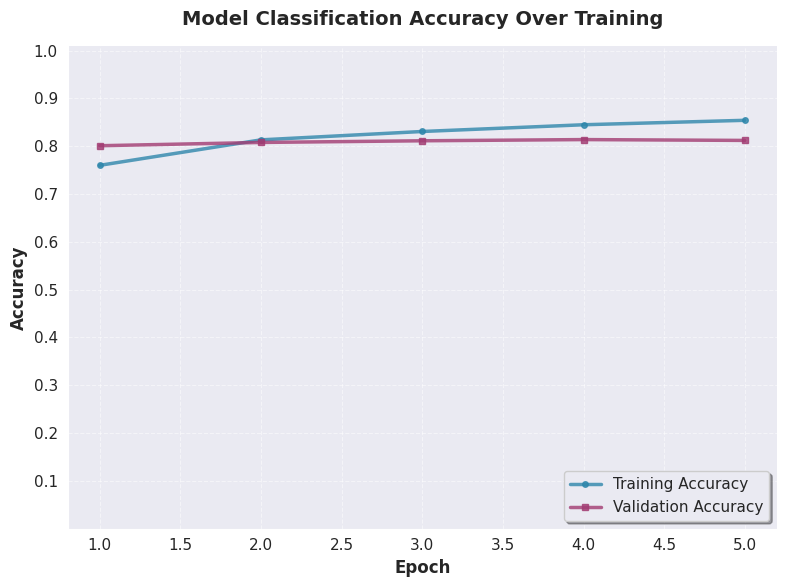

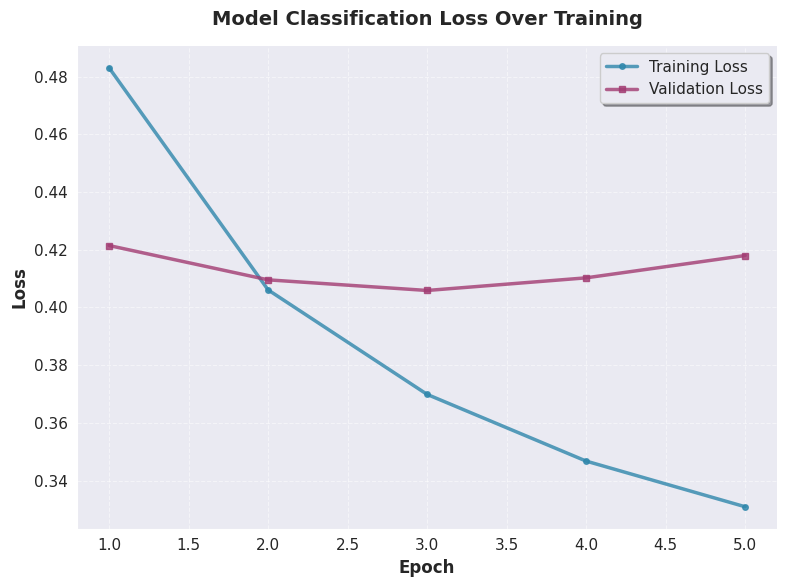

In [13]:
plot_accuracy(history, "cls_output_accuracy", "Classification")
plot_loss(history, "cls_output_loss", "Classification")

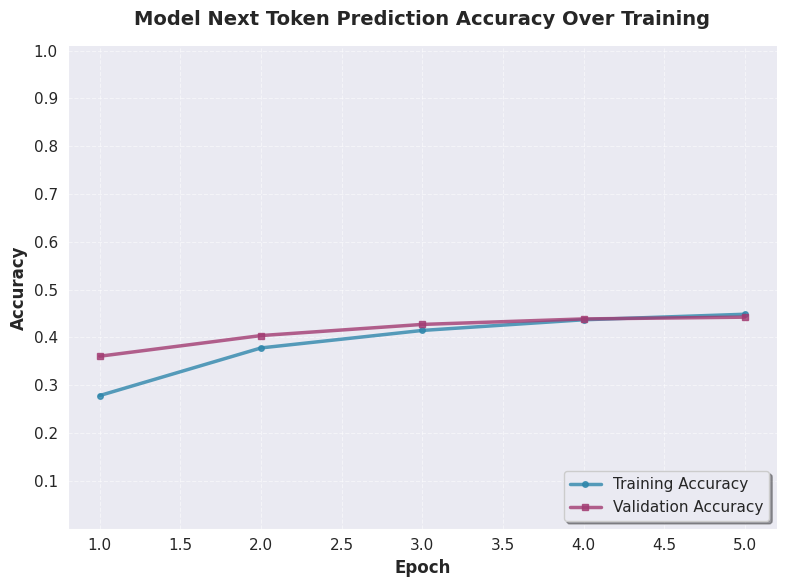

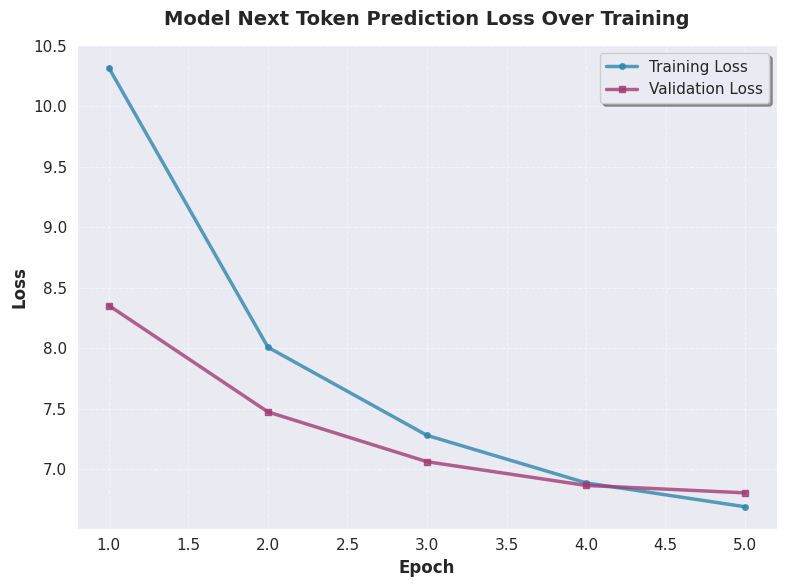

In [14]:
plot_accuracy(history, "token_pred_output_masked_accuracy", "Next Token Prediction")
plot_loss(history, "token_pred_output_loss", "Next Token Prediction")

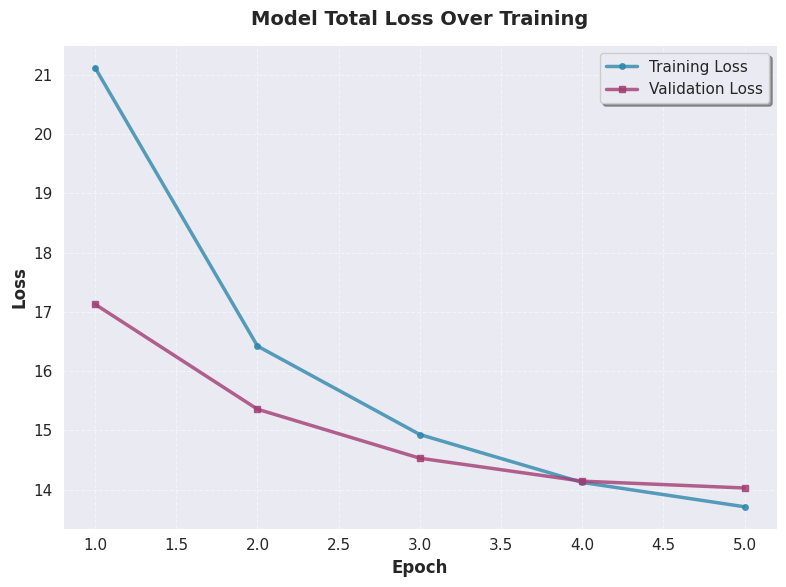

In [15]:
plot_loss(history, "loss", "Total")

In [ ]:
backbone_inputs = pretraining_model.inputs
last_layer_output = pretraining_model.get_layer("transformer_layer_11").output

embedding_model = keras.Model(
    inputs=backbone_inputs,
    outputs=last_layer_output
)

# Save this base model for further training
embedding_model.save("K-COG-BERT.keras")